In [1]:
print("Hello world")

Hello world


### Installing necessary packages

In [2]:
%pip install pefile scikit-learn pandas

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 7.1 MB/s eta 0:00:00m eta 0:00:010:01:01
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [130]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 658.2 kB/s eta 0:00:00m eta 0:00:010:00:11

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importing necessary libraries

In [ ]:
import pefile
import os
import time

import pandas as pd
import numpy as np


In [184]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score

In [ ]:
# Subroutine to check if the file is a proper PE file
def is_exe(fstring):
    try:
        file = pefile.PE(fstring)
        return True
    except Exception as e:
        print(f"Error: {e}")
        return False

### Extracting fields and forming a csv-dataset from pefiles

In [61]:
data_df = []

for filepath in os.listdir('./data/malware_dataset/benignware'):
    
    fstring = f'./data/malware_dataset/benignware/{filepath}'
    # arr = pefile.PE(fstring)

    if is_exe(fstring):
        arr = pefile.PE(fstring)
        tempdict = {}
        for section, val in arr.FILE_HEADER.dump_dict().items():
            if isinstance(val, dict):
                tempdict[section] = val.get('Value', 0)

        for section, val in arr.OPTIONAL_HEADER.dump_dict().items():
            if isinstance(val, dict):
                tempdict[section] = val.get('Value', 0)

        tempdict['label'] = 0
        data_df.append(tempdict)

for filepath in os.listdir('./data/malware_dataset/malware'):
    fstring = f'./data/malware_dataset/malware/{filepath}'
    # arr = pefile.PE(fstring)

    if is_exe(fstring):
        arr = pefile.PE(fstring)
        tempdict = {}
        for section, val in arr.FILE_HEADER.dump_dict().items():
            if isinstance(val, dict):
                tempdict[section] = val.get('Value', 0)

        for section, val in arr.OPTIONAL_HEADER.dump_dict().items():
            if isinstance(val, dict):
                tempdict[section] = val.get('Value', 0)

        tempdict['label'] = 1
        data_df.append(tempdict)


Error: 'Invalid NT Headers signature.'
Error: 'Invalid e_lfanew value, probably not a PE file'
Error: 'Invalid e_lfanew value, probably not a PE file'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid e_lfanew value, probably not a PE file'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature.'
Error: 'Invalid NT Headers signature. Probably a NE file'
Error: 'Invalid NT Headers signature

In [63]:
len(data_df)

820

In [66]:
df = pd.DataFrame(data_df)
df.head()

,Machine,NumberOfSections,TimeDateStamp,PointerToSymbolTable,NumberOfSymbols,SizeOfOptionalHeader,Characteristics,Magic,MajorLinkerVersion,MinorLinkerVersion,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,label
0,332,12,0x53C55769 [Tue Jul 15 16:31:37 2014 UTC],832512,0,224,8450,267,2,23,...,854318,3,0,2097152,4096,1048576,4096,0,16,0
1,332,12,0x53C55577 [Tue Jul 15 16:23:19 2014 UTC],29184,0,224,8450,267,2,23,...,65672,3,0,2097152,4096,1048576,4096,0,16,0
2,332,11,0x53C5555F [Tue Jul 15 16:22:55 2014 UTC],79872,0,224,8450,267,2,23,...,142750,3,0,2097152,4096,1048576,4096,0,16,0
3,332,12,0x53C55567 [Tue Jul 15 16:23:03 2014 UTC],240128,0,224,8450,267,2,23,...,284722,3,0,2097152,4096,1048576,4096,0,16,0
4,332,12,0x53C55577 [Tue Jul 15 16:23:19 2014 UTC],314880,0,224,8450,267,2,23,...,321124,3,0,2097152,4096,1048576,4096,0,16,0


### Listing the columns

In [67]:
df.columns

Index(['Machine', 'NumberOfSections', 'TimeDateStamp', 'PointerToSymbolTable',
       'NumberOfSymbols', 'SizeOfOptionalHeader', 'Characteristics', 'Magic',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'Reserved1',
       'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem',
       'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfStackCommit',
       'SizeOfHeapReserve', 'SizeOfHeapCommit', 'LoaderFlags',
       'NumberOfRvaAndSizes', 'label'],
      dtype='str')

In [ ]:
# Removing unnecessary column TimeDateStamp
df = df.drop(columns = 'TimeDateStamp')

In [ ]:
# Seperating into features and target
features = df.drop(columns = ['label'])
target = df['label']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state = 42, test_size = 0.3)

### Feature selection : Using ExtraTreesClassifier's feature importances

In [119]:
extra_tree = ExtraTreesClassifier()

In [120]:
extra_tree.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [121]:
fi = extra_tree.feature_importances_

In [122]:
feat_imp = [{
    'feat' : X_train.columns[i],
    'value' : fi[i]
} 
    for i in range(len(fi))]

In [123]:
feat_imp

[{'feat': 'Machine', 'value': np.float64(0.0)},
 {'feat': 'NumberOfSections', 'value': np.float64(0.028387576320874332)},
 {'feat': 'PointerToSymbolTable', 'value': np.float64(0.009719067499017131)},
 {'feat': 'NumberOfSymbols', 'value': np.float64(0.004236786846752355)},
 {'feat': 'SizeOfOptionalHeader', 'value': np.float64(0.0)},
 {'feat': 'Characteristics', 'value': np.float64(0.03959189905358056)},
 {'feat': 'Magic', 'value': np.float64(0.0)},
 {'feat': 'MajorLinkerVersion', 'value': np.float64(0.029041569087077765)},
 {'feat': 'MinorLinkerVersion', 'value': np.float64(0.04149374814166111)},
 {'feat': 'SizeOfCode', 'value': np.float64(0.008494107102492777)},
 {'feat': 'SizeOfInitializedData', 'value': np.float64(0.01191513072225008)},
 {'feat': 'SizeOfUninitializedData',
  'value': np.float64(0.007051319937804287)},
 {'feat': 'AddressOfEntryPoint', 'value': np.float64(0.02027179297626915)},
 {'feat': 'BaseOfCode', 'value': np.float64(0.006364217462863009)},
 {'feat': 'BaseOfData', 

In [124]:
feat_imp = sorted(feat_imp, key = lambda x : x['value'], reverse = True)

In [125]:
len(feat_imp)

36

### Selecting the 20 best features to train

In [126]:
new_feat = [x['feat'] for x in feat_imp[:20]]

In [127]:
new_feat

['DllCharacteristics',
 'MinorOperatingSystemVersion',
 'Subsystem',
 'ImageBase',
 'SizeOfStackReserve',
 'MajorOperatingSystemVersion',
 'MinorLinkerVersion',
 'Characteristics',
 'SizeOfHeaders',
 'MajorImageVersion',
 'MajorLinkerVersion',
 'NumberOfSections',
 'AddressOfEntryPoint',
 'MajorSubsystemVersion',
 'MinorImageVersion',
 'SizeOfInitializedData',
 'SizeOfImage',
 'FileAlignment',
 'CheckSum',
 'PointerToSymbolTable']

In [128]:
features = features[new_feat]

In [129]:
X_train, X_test, y_train, y_test = train_test_split(features, target)

### Training the model

In [187]:
et = ExtraTreesClassifier()

In [188]:
fit_start = time.time()

et.fit(X_train, y_train)

fit_end = time.time()

In [189]:
print("Time required to fit: %.6f ms" % ((fit_end - fit_start) * 1e3))

Time required to fit: 106.673241 ms


In [190]:
pred_start = time.time()
y_pred = et.predict(X_test)
pred_end = time.time()

In [191]:
print("Time required to predict: %.6f ms" % ((pred_end - pred_start) * 1e3))

Time required to predict: 10.400772 ms


### Classification report

In [192]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       106
           1       0.98      0.99      0.98        99

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [193]:
cm = confusion_matrix(y_test, y_pred)

In [194]:
cfd = ConfusionMatrixDisplay(cm)

### Displaying confusion matrix

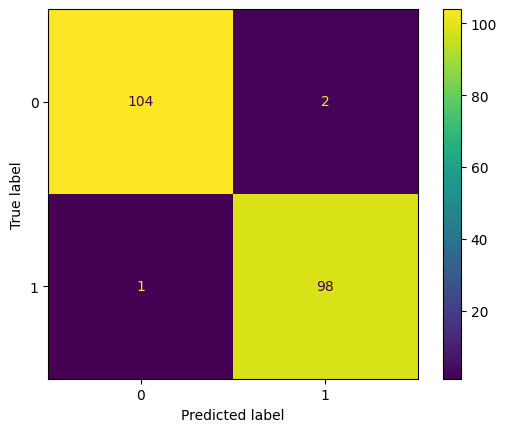

In [195]:
cfd.plot()

### The number of false positives (1s) is 2

In [162]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

### Accuracy and F1 score

In [ ]:

print(f"Accuracy: {acc}")
print(f"F1 score: {f1}")

Accuracy: 0.9804878048780488
F1 score: 0.98


In [182]:
print("Number of samples for training: ", X_train.shape[0])
print("Number of samples for testing: ", X_test.shape[0])

Number of samples for training:  615
Number of samples for testing:  205
